Plots generated successfully!

CLUSTER PROFILES (Average Survey Scores 1-10):
         Q1_Coding_Skill  Q2_Software_Adaptability  Q3_Troubleshooting  \
Cluster                                                                  
0                    6.0                       6.1                 6.2   
1                    4.6                       4.6                 4.7   
2                    4.1                       4.1                 4.1   
3                    6.6                       6.7                 6.8   

         Q4_Study_Hours  Q5_Assignment_Punctuality  Q6_Class_Attendance  
Cluster                                                                  
0                   4.5                        4.3                  4.3  
1                   6.3                        6.7                  6.6  
2                   4.7                        4.6                  4.6  
3                   6.0                        6.2                  6.2  


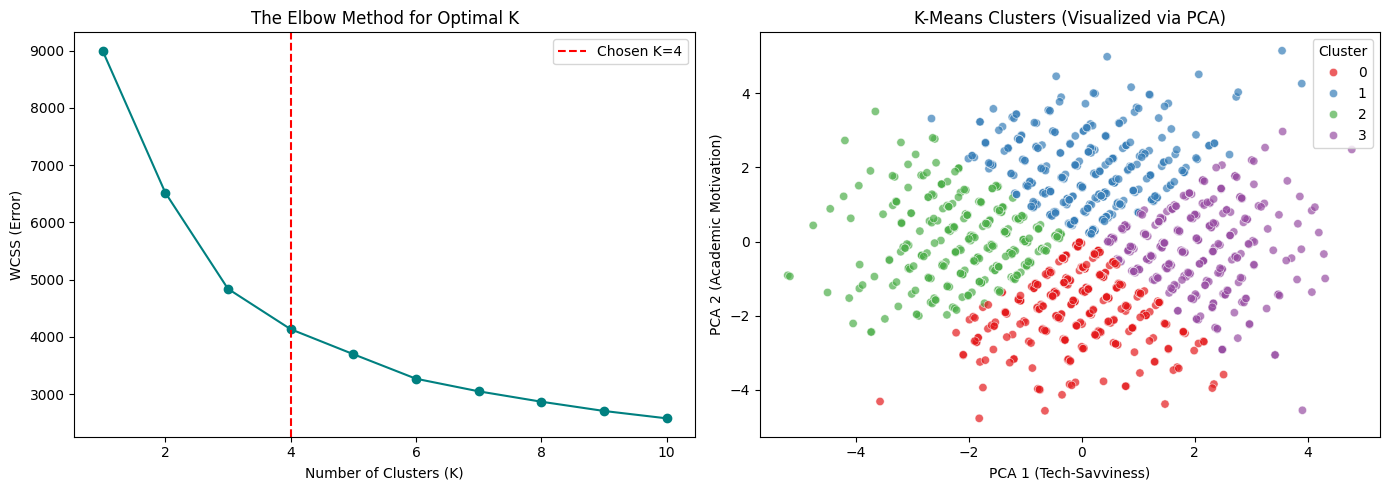

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load the survey dataset with our hidden traits
df_survey = pd.read_csv('student_survey_fa.csv')

# 2. Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_survey)

# 3. Find the optimal number of clusters using the Elbow Method
wcss = [] # Within-Cluster Sum of Squares
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 4. Fit the final K-Means model (Let's choose K=4 for the 4 quadrants of our 2 hidden traits)
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

# Add the cluster labels back to our dataframe
df_survey['Cluster'] = clusters

# 5. We need to visualize 6 dimensions in 2D, so we'll use PCA!
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_survey['PCA1'] = X_pca[:, 0]
df_survey['PCA2'] = X_pca[:, 1]

# 6. Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Elbow Method
axes[0].plot(K_range, wcss, marker='o', color='teal')
axes[0].set_title('The Elbow Method for Optimal K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS (Error)')
axes[0].axvline(x=4, color='red', linestyle='--', label='Chosen K=4')
axes[0].legend()

# Plot B: Cluster Visualization
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='Set1', data=df_survey, alpha=0.7, ax=axes[1])
axes[1].set_title('K-Means Clusters (Visualized via PCA)')
axes[1].set_xlabel('PCA 1 (Tech-Savviness)')
axes[1].set_ylabel('PCA 2 (Academic Motivation)')

plt.tight_layout()
plt.savefig('cluster_analysis.png')
print("Plots generated successfully!")

# Calculate the average survey scores for each cluster to see what they represent
cluster_profiles = df_survey.groupby('Cluster').mean().drop(columns=['PCA1', 'PCA2'])
print("\nCLUSTER PROFILES (Average Survey Scores 1-10):")
print(cluster_profiles.round(1))

In [ ]:
K-Means identified the four types of students:

Cluster 3 ("The Star Students"): High scores across the board. They are great at tech (~6.7) and highly motivated to study (~6.1).

Cluster 2 ("The Struggling Students"): Low scores everywhere. They struggle with tech (~4.1) and skip class/study rarely (~4.6).

Cluster 0 ("The Hackers / Tech Slackers"): Very high tech scores (~6.1), but terrible academic motivation (~4.3). They can code, but they sleep through class!

Cluster 1 ("The Hardworking Luddites"): Great academic motivation (~6.5), but they struggle with tech and coding (~4.6).